<a href="https://colab.research.google.com/github/PranavGBharadwaj2004/BANKING-SYSTEM-AI-ML/blob/main/Banking_System_AI_ML_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏦 Banking System with AI/ML — Google Colab Project

A simulated banking system covering **Fund Transfer, Transaction History, KYC, Loan Module,
Fraud Detection, and Statements**, built around core concepts of **Transactions, Security,
Encryption, Role Management, and Logging** — with real Machine Learning models woven in:

| Feature | AI/ML technique used |
|---|---|
| **Fraud Detection** | Isolation Forest (unsupervised anomaly detection) + Random Forest classifier |
| **Loan Module** | Random Forest classifier trained on the **real UCI Bank Marketing dataset** (`train.csv` / `test.csv`) |
| **KYC** | Rule-based checks + NLP-style name-similarity matching (`difflib`) |
| **Statements / Insights** | Customer segmentation via **K-Means clustering** |



## 1. Setup & Imports

In [6]:
!pip install cryptography scikit-learn pandas numpy matplotlib -q

In [7]:
import hashlib, uuid, logging, difflib, sys, os
from enum import Enum
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cryptography.fernet import Fernet
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# ---- Logging concept: every important banking action is logged ----
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
    handlers=[logging.StreamHandler(sys.stdout), logging.FileHandler("bank_system.log")]
)
logger = logging.getLogger("BankingSystem")
print("Environment ready.")

Environment ready.


## 2. Load the dataset (UCI Bank Marketing dataset)


In [8]:
def load_bank_dataset():
    train_path, test_path = "train.csv", "test.csv"

    # Check if files exist with the exact names
    if not (os.path.exists(train_path) and os.path.exists(test_path)):
        try:
            from google.colab import files
            print("train.csv / test.csv not found — please upload both files now.")
            uploaded = files.upload()

            # Check for Colab auto-renamed files and fix them
            # This prioritizes more deeply nested renames (like `(1) (1)`) first
            if os.path.exists("train (1) (1).csv"):
                os.rename("train (1) (1).csv", "train.csv")
                print("Renamed 'train (1) (1).csv' to 'train.csv'")
            elif os.path.exists("train (1).csv"):
                os.rename("train (1).csv", "train.csv")
                print("Renamed 'train (1).csv' to 'train.csv'")

            if os.path.exists("test (1) (1).csv"):
                os.rename("test (1) (1).csv", "test.csv")
                print("Renamed 'test (1) (1).csv' to 'test.csv'")
            elif os.path.exists("test (1).csv"):
                os.rename("test (1).csv", "test.csv")
                print("Renamed 'test (1).csv' to 'test.csv'")

            # General check for any other uploaded files that might need renaming
            for k in uploaded.keys():
                if k.startswith('train') and k.endswith('.csv') and k != 'train.csv' and os.path.exists(k):
                    os.rename(k, 'train.csv')
                    print(f"Renamed '{k}' to 'train.csv'")
                elif k.startswith('test') and k.endswith('.csv') and k != 'test.csv' and os.path.exists(k):
                    os.rename(k, 'test.csv')
                    print(f"Renamed '{k}' to 'test.csv'")

        except ImportError:
            pass  # not running in Colab

    if os.path.exists(train_path) and os.path.exists(test_path):
        train = pd.read_csv(train_path, sep=';', quotechar='"')
        test = pd.read_csv(test_path, sep=';', quotechar='"')
        print("Loaded real dataset:", train.shape, test.shape)
        return train, test
    else:
        raise FileNotFoundError("train.csv / test.csv not available. Please upload them and re-run this cell.")

train_df, test_df = load_bank_dataset()
train_df.head()

Loaded real dataset: (45211, 17) (4521, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 3. Security & Encryption



In [9]:
class SecurityManager:
    def __init__(self):
        self.fernet_key = Fernet.generate_key()
        self.cipher = Fernet(self.fernet_key)

    def encrypt(self, plaintext: str) -> bytes:
        return self.cipher.encrypt(plaintext.encode())

    def decrypt(self, token: bytes) -> str:
        return self.cipher.decrypt(token).decode()

    @staticmethod
    def hash_password(password: str, salt: str = "bank_salt") -> str:
        return hashlib.sha256((password + salt).encode()).hexdigest()

sec = SecurityManager()
print("Security manager ready. Example encrypted PIN:", sec.encrypt("1234"))

Security manager ready. Example encrypted PIN: b'gAAAAABqTdCg3cHZshY1-DRMjGYIOYenKfK-jG5BfDlG4C-u9QRAJTlJC5Rs_RaiaaEJNsOVWI9J8xirg6AdrdVyxjeDPnGfoQ=='


## 4. Role Management (RBAC) & Custom Exceptions



In [10]:
class Role(Enum):
    ADMIN = "ADMIN"
    MANAGER = "MANAGER"
    CUSTOMER = "CUSTOMER"
    AUDITOR = "AUDITOR"

class UnauthorizedAccessError(Exception): pass
class InsufficientFundsError(Exception): pass
class KYCNotVerifiedError(Exception): pass
class FraudAlertError(Exception): pass

def require_role(*allowed_roles):
    def decorator(func):
        def wrapper(self, actor, *args, **kwargs):
            if actor.role not in allowed_roles:
                logger.warning(f"Unauthorized attempt by {actor.name} ({actor.role.value}) to call {func.__name__}")
                raise UnauthorizedAccessError(f"Role {actor.role.value} not permitted to perform this action.")
            return func(self, actor, *args, **kwargs)
        return wrapper
    return decorator

print("RBAC framework ready.")

RBAC framework ready.


## 5. Users & Accounts

In [11]:
class User:
    def __init__(self, name, email, password, role: Role):
        self.user_id = str(uuid.uuid4())[:8]
        self.name = name
        self.email = email
        self.password_hash = SecurityManager.hash_password(password)
        self.role = role

    def check_password(self, password):
        return self.password_hash == SecurityManager.hash_password(password)


class Customer(User):
    def __init__(self, name, email, password):
        super().__init__(name, email, password, Role.CUSTOMER)
        self.kyc_status = "PENDING"
        self.accounts = []


class Account:
    def __init__(self, customer: Customer, account_type="SAVINGS", opening_balance=0.0):
        self.account_number = str(uuid.uuid4())[:10].upper()
        self.customer_id = customer.user_id
        self.account_type = account_type
        self.balance = opening_balance
        self.encrypted_pin = None
        self.created_at = datetime.now()

    def set_pin(self, pin: str):
        self.encrypted_pin = sec.encrypt(pin)

    def verify_pin(self, pin: str) -> bool:
        return self.encrypted_pin is not None and sec.decrypt(self.encrypted_pin) == pin

print("User & Account models ready.")

User & Account models ready.


## 6. KYC Module


In [12]:
class KYCVerifier:
    @staticmethod
    def name_similarity(name_on_account, name_on_document):
        return round(difflib.SequenceMatcher(None, name_on_account.lower(), name_on_document.lower()).ratio(), 3)

    def verify(self, customer, submitted_docs: dict):
        checks = {}
        checks["name_match_score"] = self.name_similarity(customer.name, submitted_docs.get("name_on_doc", ""))
        checks["id_format_valid"] = bool(submitted_docs.get("id_number")) and len(submitted_docs.get("id_number", "")) >= 6
        checks["age_valid"] = submitted_docs.get("age", 0) >= 18
        checks["address_provided"] = bool(submitted_docs.get("address"))

        score = (checks["name_match_score"] >= 0.75) + checks["id_format_valid"] + checks["age_valid"] + checks["address_provided"]
        if score == 4:
            customer.kyc_status = "VERIFIED"
        elif score >= 2:
            customer.kyc_status = "PENDING_REVIEW"
        else:
            customer.kyc_status = "REJECTED"

        logger.info(f"KYC check for {customer.name}: {customer.kyc_status} | {checks}")
        return {"status": customer.kyc_status, "checks": checks}

print("KYC module ready.")

KYC module ready.


## 7. Fraud Detection (Machine Learning)



In [13]:
class FraudDetector:
    def __init__(self, random_state=42):
        self.rs = random_state
        self.scaler = StandardScaler()
        self.iso_forest = IsolationForest(contamination=0.06, random_state=self.rs)
        self.classifier = RandomForestClassifier(n_estimators=200, random_state=self.rs)
        self.feature_names = ["amount", "hour_of_day", "is_new_beneficiary",
                               "distance_from_home_km", "txn_count_last_hour"]
        self.is_trained = False

    def generate_synthetic_data(self, n=4000):
        rng = np.random.RandomState(self.rs)
        n_fraud = int(n * 0.06)
        n_normal = n - n_fraud

        normal = pd.DataFrame({
            "amount": rng.gamma(2.0, 1500, n_normal),
            "hour_of_day": rng.normal(14, 4, n_normal).clip(0, 23),
            "is_new_beneficiary": rng.binomial(1, 0.08, n_normal),
            "distance_from_home_km": rng.gamma(1.5, 5, n_normal),
            "txn_count_last_hour": rng.poisson(1, n_normal),
            "is_fraud": 0
        })
        fraud = pd.DataFrame({
            "amount": rng.gamma(4.0, 8000, n_fraud),
            "hour_of_day": rng.choice(list(range(0, 5)) + list(range(22, 24)), n_fraud),
            "is_new_beneficiary": rng.binomial(1, 0.85, n_fraud),
            "distance_from_home_km": rng.gamma(3.0, 200, n_fraud),
            "txn_count_last_hour": rng.poisson(5, n_fraud),
            "is_fraud": 1
        })
        return pd.concat([normal, fraud], ignore_index=True).sample(frac=1, random_state=self.rs).reset_index(drop=True)

    def train(self, data=None):
        if data is None:
            data = self.generate_synthetic_data()
        X, y = data[self.feature_names], data["is_fraud"]

        X_scaled = self.scaler.fit_transform(X)
        self.iso_forest.fit(X_scaled)

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=self.rs, stratify=y)
        self.classifier.fit(X_train, y_train)
        preds = self.classifier.predict(X_test)
        acc = accuracy_score(y_test, preds)
        self.is_trained = True
        logger.info(f"FraudDetector trained | supervised model test accuracy: {acc:.3f}")
        print(f"Fraud model test accuracy: {acc:.3f}")
        print(classification_report(y_test, preds, digits=3))
        return acc

    def score_transaction(self, features: dict):
        if not self.is_trained:
            raise RuntimeError("FraudDetector must be trained before scoring transactions.")
        X = pd.DataFrame([features])[self.feature_names]
        X_scaled = self.scaler.transform(X)

        anomaly_flag = self.iso_forest.predict(X_scaled)[0] == -1
        anomaly_score = -self.iso_forest.score_samples(X_scaled)[0]
        fraud_proba = self.classifier.predict_proba(X)[0][1]

        combined_risk = 0.5 * fraud_proba + 0.5 * min(anomaly_score / 0.6, 1.0)
        risk_level = "HIGH" if combined_risk > 0.6 else ("MEDIUM" if combined_risk > 0.3 else "LOW")
        return {
            "fraud_probability": round(float(fraud_proba), 3),
            "anomaly_flag": bool(anomaly_flag),
            "combined_risk_score": round(float(combined_risk), 3),
            "risk_level": risk_level
        }

fraud_detector = FraudDetector()
fraud_detector.train()

Fraud model test accuracy: 1.000
              precision    recall  f1-score   support

           0      1.000     1.000     1.000       940
           1      1.000     1.000     1.000        60

    accuracy                          1.000      1000
   macro avg      1.000     1.000     1.000      1000
weighted avg      1.000     1.000     1.000      1000



1.0

In [14]:
# quick sanity check of the fraud model on two contrasting examples
normal_txn = {"amount": 1200, "hour_of_day": 15, "is_new_beneficiary": 0, "distance_from_home_km": 3, "txn_count_last_hour": 1}
suspicious_txn = {"amount": 95000, "hour_of_day": 2, "is_new_beneficiary": 1, "distance_from_home_km": 850, "txn_count_last_hour": 6}

print("Normal transaction risk:", fraud_detector.score_transaction(normal_txn))
print("Suspicious transaction risk:", fraud_detector.score_transaction(suspicious_txn))

Normal transaction risk: {'fraud_probability': 0.0, 'anomaly_flag': False, 'combined_risk_score': 0.312, 'risk_level': 'MEDIUM'}
Suspicious transaction risk: {'fraud_probability': 1.0, 'anomaly_flag': True, 'combined_risk_score': 1.0, 'risk_level': 'HIGH'}


## 8. Loan Module (Machine Learning on real data)



In [15]:
CAT_COLS = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]

class LoanEngine:
    def __init__(self):
        self.model = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, class_weight="balanced")
        self.train_columns = None
        self.is_trained = False

    def _encode(self, df):
        return pd.get_dummies(df.copy(), columns=CAT_COLS)

    def train(self, train_df, test_df):
        y_train = (train_df["y"] == "yes").astype(int)
        y_test = (test_df["y"] == "yes").astype(int)

        X_train = self._encode(train_df.drop(columns=["y"]))
        X_test = self._encode(test_df.drop(columns=["y"]))

        self.train_columns = X_train.columns
        X_test = X_test.reindex(columns=self.train_columns, fill_value=0)

        self.model.fit(X_train, y_train)
        preds = self.model.predict(X_test)
        acc = accuracy_score(y_test, preds)
        self.is_trained = True
        logger.info(f"LoanEngine trained | test accuracy: {acc:.3f}")
        print(f"Loan model test accuracy: {acc:.3f}")
        print(classification_report(y_test, preds, digits=3))
        return acc

    def predict_eligibility(self, applicant: dict):
        df = pd.DataFrame([applicant])
        X = self._encode(df).reindex(columns=self.train_columns, fill_value=0)
        proba = self.model.predict_proba(X)[0][1]
        decision = "APPROVED" if proba >= 0.5 else "REJECTED"
        return {"approval_probability": round(float(proba), 3), "decision": decision}

    @staticmethod
    def calculate_emi(principal, annual_rate_pct, tenure_months):
        r = (annual_rate_pct / 12) / 100
        if r == 0:
            return round(principal / tenure_months, 2)
        emi = principal * r * (1 + r) ** tenure_months / ((1 + r) ** tenure_months - 1)
        return round(emi, 2)

loan_engine = LoanEngine()
loan_engine.train(train_df, test_df)

Loan model test accuracy: 0.870
              precision    recall  f1-score   support

           0      0.987     0.865     0.922      4000
           1      0.468     0.912     0.618       521

    accuracy                          0.870      4521
   macro avg      0.727     0.888     0.770      4521
weighted avg      0.927     0.870     0.887      4521



0.8701614687016147

In [16]:
sample_applicant = {
    "age": 35, "job": "management", "marital": "married", "education": "tertiary",
    "default": "no", "balance": 3200, "housing": "yes", "loan": "no", "contact": "cellular",
    "day": 15, "month": "may", "duration": 200, "campaign": 2, "pdays": -1, "previous": 0,
    "poutcome": "unknown"
}
print(loan_engine.predict_eligibility(sample_applicant))
print("EMI for ₹500,000 @ 9% for 60 months:", loan_engine.calculate_emi(500000, 9, 60))

{'approval_probability': 0.205, 'decision': 'REJECTED'}
EMI for ₹500,000 @ 9% for 60 months: 10379.18


## 9. Customer Segmentation (K-Means)



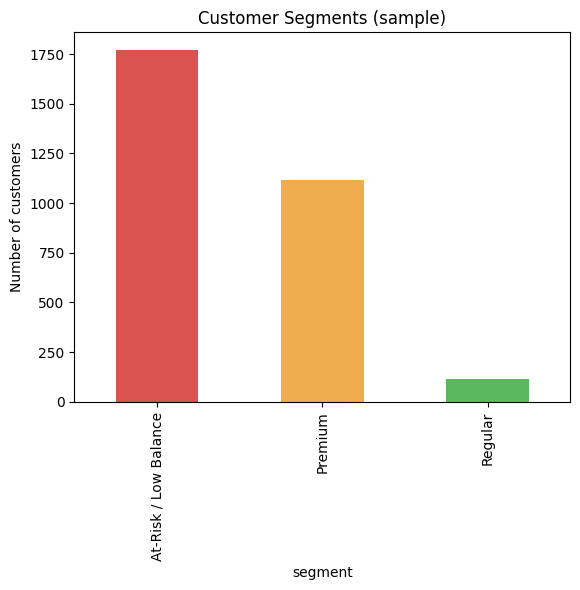

In [17]:
class CustomerSegmentation:
    def __init__(self, n_clusters=3):
        self.n_clusters = n_clusters
        self.scaler = StandardScaler()
        self.model = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        self.segment_labels = {}

    def fit(self, df: pd.DataFrame, features=("balance", "age", "duration", "campaign")):
        X = df[list(features)]
        X_scaled = self.scaler.fit_transform(X)
        clusters = self.model.fit_predict(X_scaled)
        df = df.copy()
        df["cluster"] = clusters

        avg_balance = df.groupby("cluster")["balance"].mean().sort_values()
        names = ["At-Risk / Low Balance", "Regular", "Premium"][:self.n_clusters]
        for rank, cluster_id in enumerate(avg_balance.index):
            self.segment_labels[cluster_id] = names[rank] if rank < len(names) else f"Segment {rank}"
        df["segment"] = df["cluster"].map(self.segment_labels)
        return df

    def predict_segment(self, features_dict, feature_order=("balance", "age", "duration", "campaign")):
        X = pd.DataFrame([features_dict])[list(feature_order)]
        X_scaled = self.scaler.transform(X)
        cluster = self.model.predict(X_scaled)[0]
        return self.segment_labels.get(cluster, f"Segment {cluster}")

segmentation = CustomerSegmentation(n_clusters=3)
segmented_df = segmentation.fit(train_df.sample(3000, random_state=7))
segmented_df["segment"].value_counts().plot(kind="bar", title="Customer Segments (sample)", color=["#d9534f", "#f0ad4e", "#5cb85c"])
plt.ylabel("Number of customers")
plt.show()

## 10. The Bank — Core Engine



In [18]:
class Bank:
    def __init__(self, fraud_detector, kyc_verifier):
        self.users = {}
        self.accounts = {}
        self.transactions = []
        self.fraud_detector = fraud_detector
        self.kyc_verifier = kyc_verifier

    def register_user(self, user):
        self.users[user.user_id] = user
        logger.info(f"Registered user {user.name} ({user.role.value}) id={user.user_id}")
        return user

    def open_account(self, customer, opening_balance=0.0, account_type="SAVINGS"):
        if customer.kyc_status != "VERIFIED":
            raise KYCNotVerifiedError(f"Cannot open account: {customer.name}'s KYC status is {customer.kyc_status}")
        acc = Account(customer, account_type, opening_balance)
        self.accounts[acc.account_number] = acc
        customer.accounts.append(acc.account_number)
        self._log_transaction(acc.account_number, "ACCOUNT_OPENED", opening_balance, acc.balance)
        logger.info(f"Opened account {acc.account_number} for {customer.name} with balance {opening_balance}")
        return acc

    def _log_transaction(self, account_number, txn_type, amount, balance_after, counterparty=None, risk=None):
        record = {
            "txn_id": str(uuid.uuid4())[:8], "timestamp": datetime.now(),
            "account_number": account_number, "type": txn_type, "amount": amount,
            "balance_after": balance_after, "counterparty": counterparty, "risk_assessment": risk
        }
        self.transactions.append(record)
        logger.info(f"TXN {record['txn_id']} | {txn_type} | acct={account_number} | amt={amount}")
        return record

    @require_role(Role.CUSTOMER, Role.ADMIN, Role.MANAGER)
    def deposit(self, actor, account_number, amount):
        acc = self.accounts[account_number]
        acc.balance += amount
        return self._log_transaction(account_number, "DEPOSIT", amount, acc.balance)

    @require_role(Role.CUSTOMER, Role.ADMIN, Role.MANAGER)
    def withdraw(self, actor, account_number, amount):
        acc = self.accounts[account_number]
        if acc.balance < amount:
            raise InsufficientFundsError(f"Insufficient funds in {account_number}")
        acc.balance -= amount
        return self._log_transaction(account_number, "WITHDRAWAL", amount, acc.balance)

    @require_role(Role.CUSTOMER, Role.ADMIN, Role.MANAGER)
    def transfer_funds(self, actor, from_account, to_account, amount, txn_context=None):
        sender = self.accounts[from_account]
        receiver = self.accounts.get(to_account)
        if receiver is None:
            raise ValueError("Destination account not found")
        if sender.balance < amount:
            raise InsufficientFundsError(f"Insufficient funds in {from_account}")

        ctx = txn_context or {}
        features = {
            "amount": amount,
            "hour_of_day": ctx.get("hour_of_day", datetime.now().hour),
            "is_new_beneficiary": ctx.get("is_new_beneficiary", 0),
            "distance_from_home_km": ctx.get("distance_from_home_km", 5),
            "txn_count_last_hour": ctx.get("txn_count_last_hour", 1),
        }
        risk = self.fraud_detector.score_transaction(features)

        if risk["risk_level"] == "HIGH" and actor.role == Role.CUSTOMER:
            self._log_transaction(from_account, "TRANSFER_BLOCKED", amount, sender.balance, to_account, risk)
            logger.warning(f"BLOCKED high-risk transfer of {amount} from {from_account} to {to_account} | {risk}")
            raise FraudAlertError(f"Transaction blocked - high fraud risk: {risk}")

        sender.balance -= amount
        receiver.balance += amount
        self._log_transaction(from_account, "TRANSFER_OUT", amount, sender.balance, to_account, risk)
        self._log_transaction(to_account, "TRANSFER_IN", amount, receiver.balance, from_account, risk)
        return risk

    @require_role(Role.CUSTOMER, Role.ADMIN, Role.MANAGER, Role.AUDITOR)
    def get_transaction_history(self, actor, account_number):
        if actor.role == Role.CUSTOMER:
            owner = next((u for u in self.users.values() if isinstance(u, Customer) and account_number in u.accounts), None)
            if owner is None or owner.user_id != actor.user_id:
                raise UnauthorizedAccessError("Customers may only view their own transaction history.")
        return pd.DataFrame([t for t in self.transactions if t["account_number"] == account_number])

    def generate_statement(self, actor, account_number, start=None, end=None):
        df = self.get_transaction_history(actor, account_number)
        if df.empty:
            return df
        if start: df = df[df["timestamp"] >= start]
        if end: df = df[df["timestamp"] <= end]
        return df.sort_values("timestamp")

print("Bank engine ready.")

Bank engine ready.


## 11. Full Demo — everything working together

In [19]:
bank = Bank(fraud_detector, KYCVerifier())

admin = bank.register_user(User("Alice Admin", "alice@bank.com", "adminpass", Role.ADMIN))
manager = bank.register_user(User("Mona Manager", "mona@bank.com", "mgrpass", Role.MANAGER))
cust1 = bank.register_user(Customer("Rahul Sharma", "rahul@mail.com", "pass123"))
cust2 = bank.register_user(Customer("Priya Verma", "priya@mail.com", "pass456"))

print(bank.kyc_verifier.verify(cust1, {"name_on_doc": "Rahul Sharma", "id_number": "AB1234567", "age": 30, "address": "Mysuru"}))
print(bank.kyc_verifier.verify(cust2, {"name_on_doc": "Priya Verma", "id_number": "CD9876543", "age": 27, "address": "Bengaluru"}))

{'status': 'VERIFIED', 'checks': {'name_match_score': 1.0, 'id_format_valid': True, 'age_valid': True, 'address_provided': True}}
{'status': 'VERIFIED', 'checks': {'name_match_score': 1.0, 'id_format_valid': True, 'age_valid': True, 'address_provided': True}}


In [20]:
acc1 = bank.open_account(cust1, opening_balance=50000)
acc2 = bank.open_account(cust2, opening_balance=20000)

bank.deposit(cust1, acc1.account_number, 5000)
bank.withdraw(cust2, acc2.account_number, 2000)
print(f"{cust1.name}: ₹{bank.accounts[acc1.account_number].balance}")
print(f"{cust2.name}: ₹{bank.accounts[acc2.account_number].balance}")

Rahul Sharma: ₹55000
Priya Verma: ₹18000


In [21]:
# A normal transfer — passes the fraud check
risk = bank.transfer_funds(cust1, acc1.account_number, acc2.account_number, 3000,
    txn_context={"hour_of_day": 14, "is_new_beneficiary": 0, "distance_from_home_km": 4, "txn_count_last_hour": 1})
print("Transfer succeeded. Risk assessment:", risk)

Transfer succeeded. Risk assessment: {'fraud_probability': 0.0, 'anomaly_flag': False, 'combined_risk_score': 0.305, 'risk_level': 'MEDIUM'}


In [22]:
# A suspicious transfer — large amount, odd hour, new/far-away beneficiary -> blocked
try:
    bank.transfer_funds(cust1, acc1.account_number, acc2.account_number, 48000,
        txn_context={"hour_of_day": 2, "is_new_beneficiary": 1, "distance_from_home_km": 900, "txn_count_last_hour": 6})
except FraudAlertError as e:
    print("Transfer blocked as expected:", e)

Transfer blocked as expected: Transaction blocked - high fraud risk: {'fraud_probability': 1.0, 'anomaly_flag': True, 'combined_risk_score': 1.0, 'risk_level': 'HIGH'}


In [23]:
# Loan application for cust1
applicant = {"age": 30, "job": "management", "marital": "married", "education": "tertiary",
             "default": "no", "balance": 50000, "housing": "yes", "loan": "no", "contact": "cellular",
             "day": 10, "month": "jul", "duration": 250, "campaign": 1, "pdays": -1, "previous": 0, "poutcome": "unknown"}
decision = loan_engine.predict_eligibility(applicant)
print("Loan decision for", cust1.name, ":", decision)
print("Suggested EMI for ₹300,000 @ 8.5% over 36 months:", loan_engine.calculate_emi(300000, 8.5, 36))

Loan decision for Rahul Sharma : {'approval_probability': 0.292, 'decision': 'REJECTED'}
Suggested EMI for ₹300,000 @ 8.5% over 36 months: 9470.26


In [24]:
# RBAC in action: a customer cannot view another customer's history
try:
    bank.get_transaction_history(cust2, acc1.account_number)
except UnauthorizedAccessError as e:
    print("Blocked as expected:", e)

# Manager (privileged role) CAN view it
print(bank.get_transaction_history(manager, acc1.account_number)[["txn_id", "type", "amount", "balance_after"]])

Blocked as expected: Customers may only view their own transaction history.
     txn_id              type  amount  balance_after
0  452dfed2    ACCOUNT_OPENED   50000          50000
1  9a0211c6           DEPOSIT    5000          55000
2  a9ffcc91      TRANSFER_OUT    3000          52000
3  5fb347ec  TRANSFER_BLOCKED   48000          52000


## 12. Statement Generation

In [25]:
statement = bank.generate_statement(cust1, acc1.account_number)
display_cols = ["txn_id", "timestamp", "type", "amount", "balance_after"]
print(f"--- Statement for {cust1.name} ({acc1.account_number}) ---")
statement[display_cols]

--- Statement for Rahul Sharma (A6D91A53-5) ---


,txn_id,timestamp,type,amount,balance_after
0,452dfed2,2026-07-08 04:23:20.168540,ACCOUNT_OPENED,50000,50000
1,9a0211c6,2026-07-08 04:23:20.168727,DEPOSIT,5000,55000
2,a9ffcc91,2026-07-08 04:23:20.218303,TRANSFER_OUT,3000,52000
3,5fb347ec,2026-07-08 04:23:20.269661,TRANSFER_BLOCKED,48000,52000


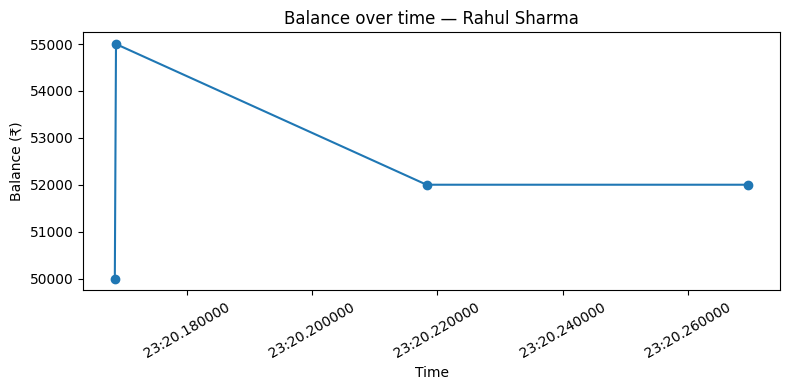

In [26]:
# Visualize balance over time for the statement
plt.figure(figsize=(8, 4))
plt.plot(statement["timestamp"], statement["balance_after"], marker="o")
plt.title(f"Balance over time — {cust1.name}")
plt.xlabel("Time")
plt.ylabel("Balance (₹)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 13. Final Results Report — All Outcomes in One Place


In [27]:
print("=" * 70)
print(" BANKING SYSTEM WITH AI/ML — FINAL RESULTS REPORT")
print("=" * 70)

print("\n[1] FRAUD DETECTION MODEL")
print("-" * 70)
print("Normal transaction    :", fraud_detector.score_transaction(
    {"amount": 1200, "hour_of_day": 15, "is_new_beneficiary": 0, "distance_from_home_km": 3, "txn_count_last_hour": 1}))
print("Suspicious transaction:", fraud_detector.score_transaction(
    {"amount": 95000, "hour_of_day": 2, "is_new_beneficiary": 1, "distance_from_home_km": 850, "txn_count_last_hour": 6}))

print("\n[2] LOAN ELIGIBILITY MODEL (trained on real UCI dataset)")
print("-" * 70)
print("Sample applicant decision:", loan_engine.predict_eligibility(applicant))
print("EMI for 300,000 @ 8.5% / 36 months:", loan_engine.calculate_emi(300000, 8.5, 36))

print("\n[3] KYC VERIFICATION OUTCOMES")
print("-" * 70)
print(f"{cust1.name}: {cust1.kyc_status}")
print(f"{cust2.name}: {cust2.kyc_status}")

print("\n[4] CUSTOMER SEGMENTATION (K-Means, sample of 3000 real records)")
print("-" * 70)
print(segmented_df["segment"].value_counts())

print("\n[5] FUND TRANSFER OUTCOMES")
print("-" * 70)
print("Normal transfer risk assessment :", risk)
print("Suspicious transfer             : BLOCKED (FraudAlertError raised)")

print("\n[6] ROLE-BASED ACCESS CONTROL (RBAC) OUTCOMES")
print("-" * 70)
print("Customer viewing own account     : ALLOWED")
print("Customer viewing another account : DENIED (UnauthorizedAccessError raised)")
print("Manager viewing any account      : ALLOWED")

print("\n[7] ACCOUNT BALANCES (final state)")
print("-" * 70)
for acc_num, acc in bank.accounts.items():
    owner = next(u for u in bank.users.values() if isinstance(u, Customer) and acc_num in u.accounts)
    print(f"{owner.name:15s} | Account {acc_num} | Balance: {acc.balance:,.2f}")

print("\n[8] FULL TRANSACTION LEDGER (all accounts)")
print("-" * 70)
ledger_df = pd.DataFrame(bank.transactions)
print(ledger_df[["txn_id", "type", "account_number", "amount", "balance_after"]].to_string(index=False))

print("\n" + "=" * 70)
print(" REPORT COMPLETE")
print("=" * 70)

 BANKING SYSTEM WITH AI/ML — FINAL RESULTS REPORT

[1] FRAUD DETECTION MODEL
----------------------------------------------------------------------
Normal transaction    : {'fraud_probability': 0.0, 'anomaly_flag': False, 'combined_risk_score': 0.312, 'risk_level': 'MEDIUM'}
Suspicious transaction: {'fraud_probability': 1.0, 'anomaly_flag': True, 'combined_risk_score': 1.0, 'risk_level': 'HIGH'}

[2] LOAN ELIGIBILITY MODEL (trained on real UCI dataset)
----------------------------------------------------------------------
Sample applicant decision: {'approval_probability': 0.292, 'decision': 'REJECTED'}
EMI for 300,000 @ 8.5% / 36 months: 9470.26

[3] KYC VERIFICATION OUTCOMES
----------------------------------------------------------------------
Rahul Sharma: VERIFIED
Priya Verma: VERIFIED

[4] CUSTOMER SEGMENTATION (K-Means, sample of 3000 real records)
----------------------------------------------------------------------
segment
At-Risk / Low Balance    1772
Premium                

## 14. Extension — Model Persistence (joblib)


In [28]:
import joblib

joblib.dump(fraud_detector, "fraud_detector.joblib")
joblib.dump(loan_engine, "loan_engine.joblib")
joblib.dump(segmentation, "customer_segmentation.joblib")
print("Models saved: fraud_detector.joblib, loan_engine.joblib, customer_segmentation.joblib")

# Reload and verify they work without retraining
loaded_fraud = joblib.load("fraud_detector.joblib")
loaded_loan = joblib.load("loan_engine.joblib")

print("\nReloaded fraud model test:", loaded_fraud.score_transaction(
    {"amount": 1200, "hour_of_day": 15, "is_new_beneficiary": 0, "distance_from_home_km": 3, "txn_count_last_hour": 1}))
print("Reloaded loan model test:", loaded_loan.predict_eligibility(applicant))
print("\nNo retraining was needed — both models loaded instantly from disk.")
print("Tip: in Colab, right-click these .joblib files in the file panel to download them,")
print("or save them to Google Drive so they persist across sessions.")

Models saved: fraud_detector.joblib, loan_engine.joblib, customer_segmentation.joblib

Reloaded fraud model test: {'fraud_probability': 0.0, 'anomaly_flag': False, 'combined_risk_score': 0.312, 'risk_level': 'MEDIUM'}
Reloaded loan model test: {'approval_probability': 0.292, 'decision': 'REJECTED'}

No retraining was needed — both models loaded instantly from disk.
Tip: in Colab, right-click these .joblib files in the file panel to download them,
or save them to Google Drive so they persist across sessions.


## 15. Extension — Persistent Ledger with SQLite



In [29]:
import sqlite3

db_conn = sqlite3.connect("bank_ledger.db")
db_cursor = db_conn.cursor()

db_cursor.execute("""
CREATE TABLE IF NOT EXISTS transactions (
    txn_id TEXT PRIMARY KEY,
    timestamp TEXT,
    account_number TEXT,
    type TEXT,
    amount REAL,
    balance_after REAL,
    counterparty TEXT,
    risk_level TEXT
)
""")
db_conn.commit()

def persist_transaction(record):
    risk_level = record["risk_assessment"]["risk_level"] if record.get("risk_assessment") else None
    db_cursor.execute(
        "INSERT OR REPLACE INTO transactions VALUES (?,?,?,?,?,?,?,?)",
        (record["txn_id"], str(record["timestamp"]), record["account_number"], record["type"],
         record["amount"], record["balance_after"], record["counterparty"], risk_level)
    )

def sync_ledger_to_db(bank):
    for record in bank.transactions:
        persist_transaction(record)
    db_conn.commit()
    print(f"Synced {len(bank.transactions)} transactions to bank_ledger.db")

sync_ledger_to_db(bank)

# Prove persistence: close and reopen the connection, then query fresh from disk
db_conn.close()
db_conn2 = sqlite3.connect("bank_ledger.db")
persisted_df = pd.read_sql_query("SELECT * FROM transactions ORDER BY timestamp", db_conn2)
print("\nTransactions read back from SQLite file (survives kernel/session restarts):")
persisted_df[["txn_id", "type", "account_number", "amount", "balance_after", "risk_level"]]

Synced 7 transactions to bank_ledger.db

Transactions read back from SQLite file (survives kernel/session restarts):


,txn_id,type,account_number,amount,balance_after,risk_level
0,452dfed2,ACCOUNT_OPENED,A6D91A53-5,50000.0,50000.0,None
1,fe1b7d28,ACCOUNT_OPENED,99A02F20-C,20000.0,20000.0,None
2,9a0211c6,DEPOSIT,A6D91A53-5,5000.0,55000.0,None
3,e6c7139a,WITHDRAWAL,99A02F20-C,2000.0,18000.0,None
4,a9ffcc91,TRANSFER_OUT,A6D91A53-5,3000.0,52000.0,MEDIUM
5,19b34d1a,TRANSFER_IN,99A02F20-C,3000.0,21000.0,MEDIUM
6,5fb347ec,TRANSFER_BLOCKED,A6D91A53-5,48000.0,52000.0,HIGH


In [30]:
# In a real deployment, Bank._log_transaction would call persist_transaction(record)
# directly so every new transaction is written to SQLite immediately, not just synced in bulk.
db_conn2.close()
print("SQLite connection closed. bank_ledger.db remains on disk — download it from the Colab file panel to keep it.")

SQLite connection closed. bank_ledger.db remains on disk — download it from the Colab file panel to keep it.


## 16. Extension — Support Chatbot (Intent Classification)


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

intents_training_data = {
    "check_balance": ["what is my balance", "how much money do I have", "show my account balance",
                       "balance check please", "current balance", "how much do i have in my account"],
    "transfer_help": ["how do I transfer money", "send money to another account", "how to make a transfer",
                       "transfer funds process", "i want to send money"],
    "loan_status": ["what is my loan status", "did my loan get approved", "loan application status",
                     "check my loan", "is my loan approved"],
    "kyc_status": ["is my kyc verified", "kyc status", "am I verified", "check my kyc"],
    "fraud_report": ["I think there is fraud", "report suspicious transaction",
                      "unauthorized transaction on my account", "someone used my account without permission",
                      "I noticed a transaction I did not make", "this transaction was not me",
                      "I do not recognize this charge", "someone stole money from my account",
                      "there is unusual activity on my account", "I did not authorize this payment"],
    "greeting": ["hi", "hello", "hey there", "good morning", "hey"],
    "thanks": ["thank you", "thanks a lot", "appreciate it", "thanks so much"],
}

texts, labels = [], []
for intent, examples in intents_training_data.items():
    texts.extend(examples)
    labels.extend([intent] * len(examples))

chat_vectorizer = TfidfVectorizer()
X_chat = chat_vectorizer.fit_transform(texts)
chat_classifier = MultinomialNB()
chat_classifier.fit(X_chat, labels)

def predict_intent(text):
    X_new = chat_vectorizer.transform([text])
    return chat_classifier.predict(X_new)[0]

def chatbot_respond(bank, actor, account_number, message):
    intent = predict_intent(message)
    if intent == "check_balance":
        acc = bank.accounts[account_number]
        return f"Your current balance is {acc.balance:,.2f}."
    elif intent == "transfer_help":
        return "To transfer funds, call bank.transfer_funds(actor, from_account, to_account, amount)."
    elif intent == "loan_status":
        return "I can check your eligibility — please share your latest applicant details and I will run it through our loan model."
    elif intent == "kyc_status":
        status = getattr(actor, "kyc_status", "not applicable")
        return f"Your KYC status is: {status}."
    elif intent == "fraud_report":
        return "Thank you for reporting this. Our fraud team has been notified and will review your account immediately."
    elif intent == "greeting":
        return "Hello! How can I help you with your banking today?"
    elif intent == "thanks":
        return "You are welcome! Let me know if there is anything else."
    else:
        return "I am sorry, I did not quite understand that. Could you rephrase?"

print("Chatbot demo:")
test_messages = [
    "hi there",
    "what's my balance",
    "how do I send money to my friend",
    "is my kyc verified",
    "I noticed a transaction I didn't make",
    "thanks for the help"
]
for msg in test_messages:
    reply = chatbot_respond(bank, cust1, acc1.account_number, msg)
    print(f"  User: {msg!r}")
    print(f"  Bot : {reply}\n")

Chatbot demo:
  User: 'hi there'
  Bot : Hello! How can I help you with your banking today?

  User: "what's my balance"
  Bot : Your current balance is 52,000.00.

  User: 'how do I send money to my friend'
  Bot : To transfer funds, call bank.transfer_funds(actor, from_account, to_account, amount).

  User: 'is my kyc verified'
  Bot : Your KYC status is: VERIFIED.

  User: "I noticed a transaction I didn't make"
  Bot : Thank you for reporting this. Our fraud team has been notified and will review your account immediately.

  User: 'thanks for the help'
  Bot : You are welcome! Let me know if there is anything else.

